# ML for Hydrodynamics: ET vs GN Comparison

Results from single-geometry training on `nbody_open` (500 epochs each).

- **ET** (Equivariant Transformer): learns both isotropic and anisotropic components of the RPY mobility tensor
- **GN** (SchNet / TorchMD_GN): isotropic message passing — cannot represent the anisotropic $b(r)\hat{r}\otimes\hat{r}$ term

In [2]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Style
plt.rcParams.update({
    "font.family": "serif",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

# Result paths
et_dir = Path("results/torchmd_et_single/run_002")
gn_dir = Path("results/torchmd_gn_single/run_019")
plot_dir = Path("results/comparison_plots")
plot_dir.mkdir(parents=True, exist_ok=True)

# Load data
et_history = pd.read_csv(et_dir / "history.csv")
gn_history = pd.read_csv(gn_dir / "history.csv")

with open(et_dir / "eval_single_step.json") as f:
    et_eval = json.load(f)["nbody_open"]
with open(gn_dir / "eval_single_step.json") as f:
    gn_eval = json.load(f)["nbody_open"]

with open(et_dir / "eval_scaling.json") as f:
    et_scaling = json.load(f)
with open(gn_dir / "eval_scaling.json") as f:
    gn_scaling = json.load(f)

print("Data loaded successfully.")

Data loaded successfully.


KeyError: ['val_loss']

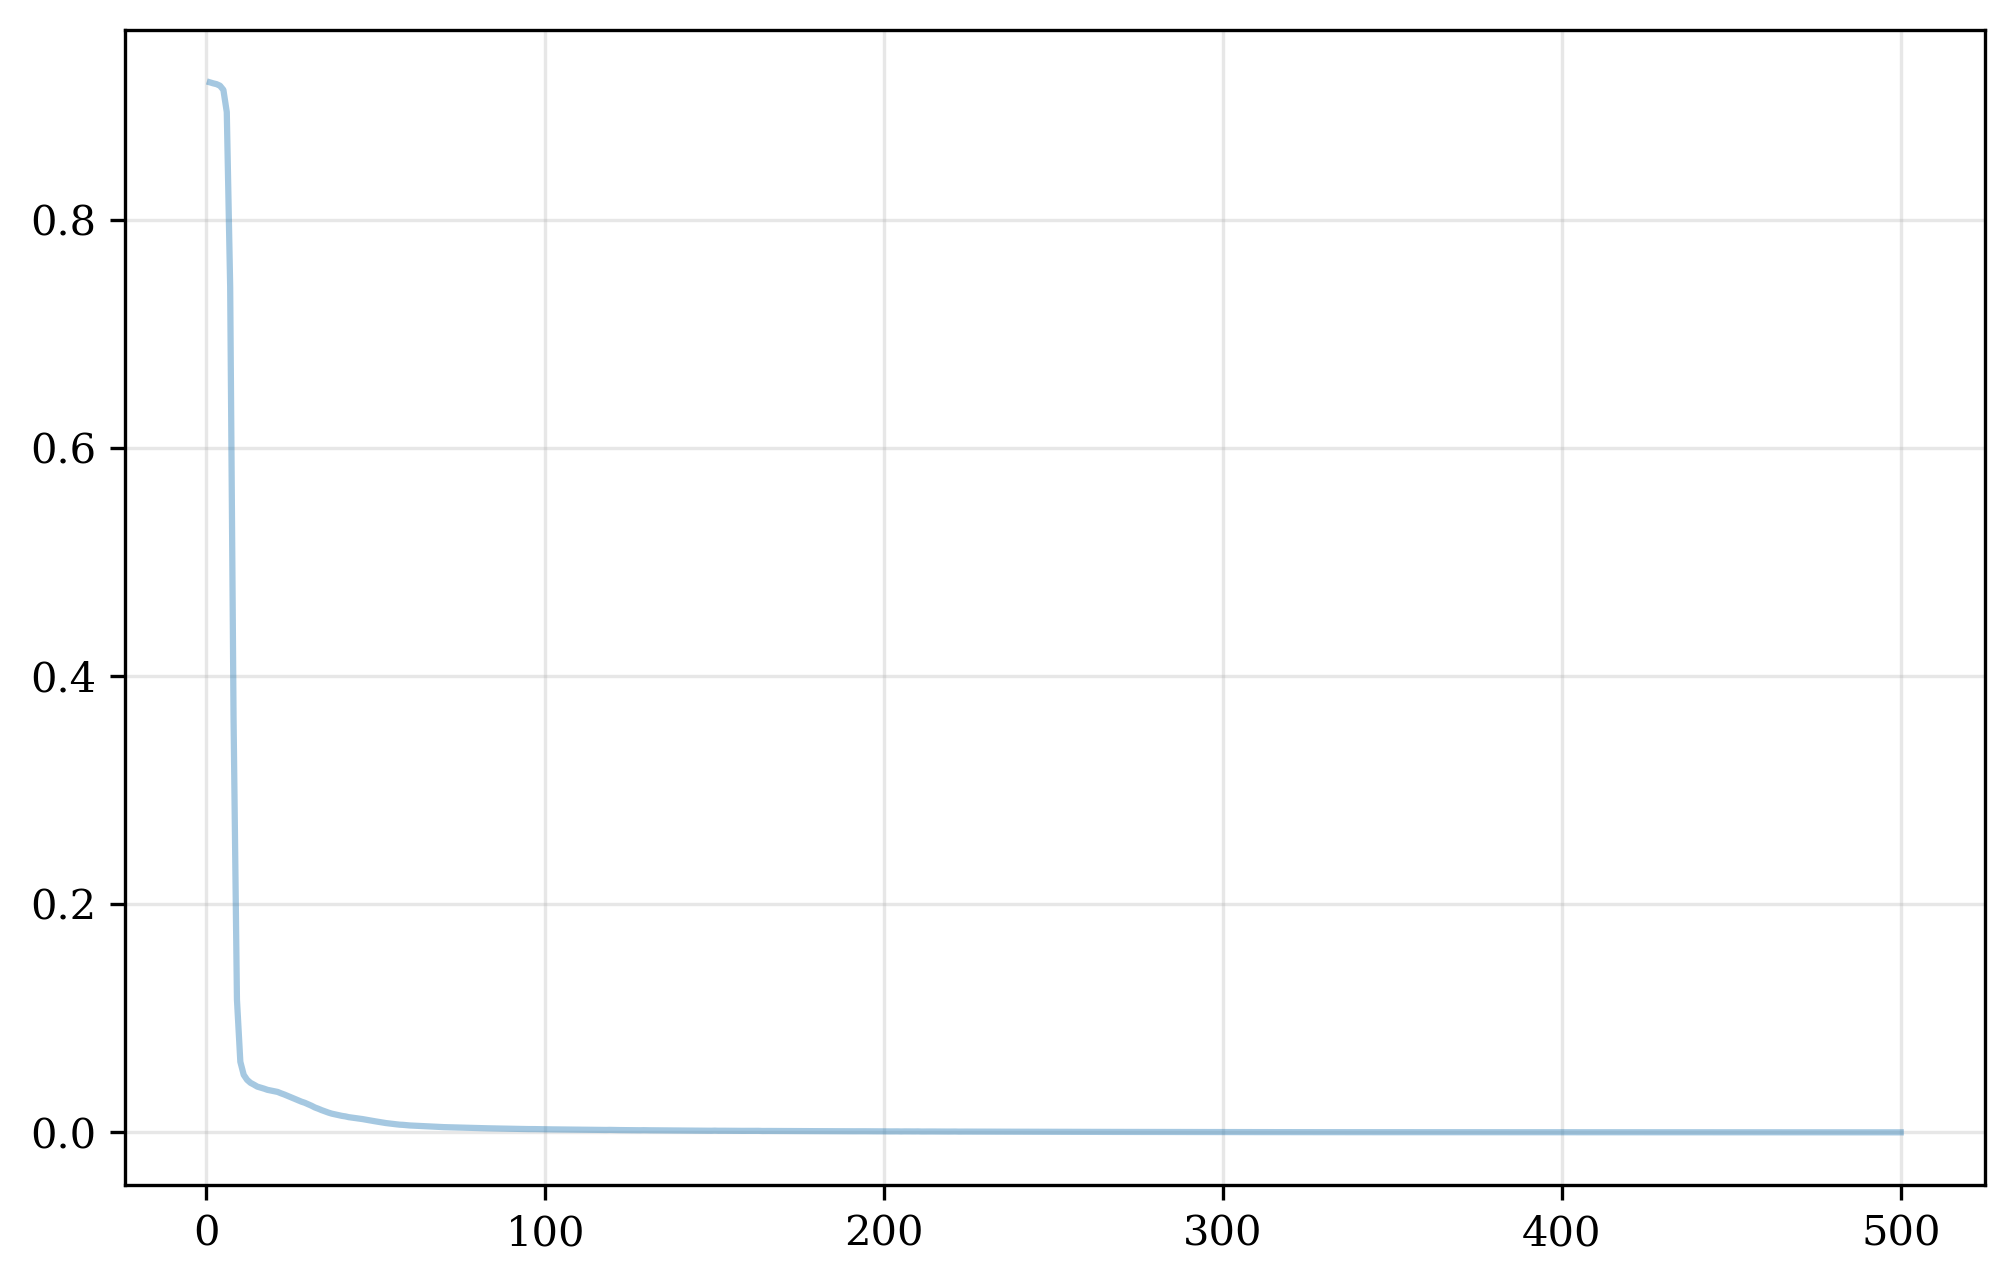

In [3]:
## Training Curves

fig, ax = plt.subplots(figsize=(8, 5))

# ET
ax.plot(et_history["epoch"], et_history["train_loss"], color="tab:blue", alpha=0.4, label="ET train")
et_val = et_history.dropna(subset=["val_loss"])
ax.plot(et_val["epoch"], et_val["val_loss"], color="tab:blue", linewidth=2, label="ET val")

# GN
ax.plot(gn_history["epoch"], gn_history["train_loss"], color="tab:orange", alpha=0.4, label="GN train")
gn_val = gn_history.dropna(subset=["val_loss"])
ax.plot(gn_val["epoch"], gn_val["val_loss"], color="tab:orange", linewidth=2, label="GN val")

# Baselines
ax.axhline(1.0, color="gray", linestyle="--", alpha=0.5, label="Predict-zero baseline")

ax.set_yscale("log")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss (log scale)")
ax.set_title("Training Curves: ET vs GN (nbody_open)")
ax.legend(loc="upper right")

fig.savefig(plot_dir / "training_curves.png")
fig.savefig(plot_dir / "training_curves.pdf")
plt.show()

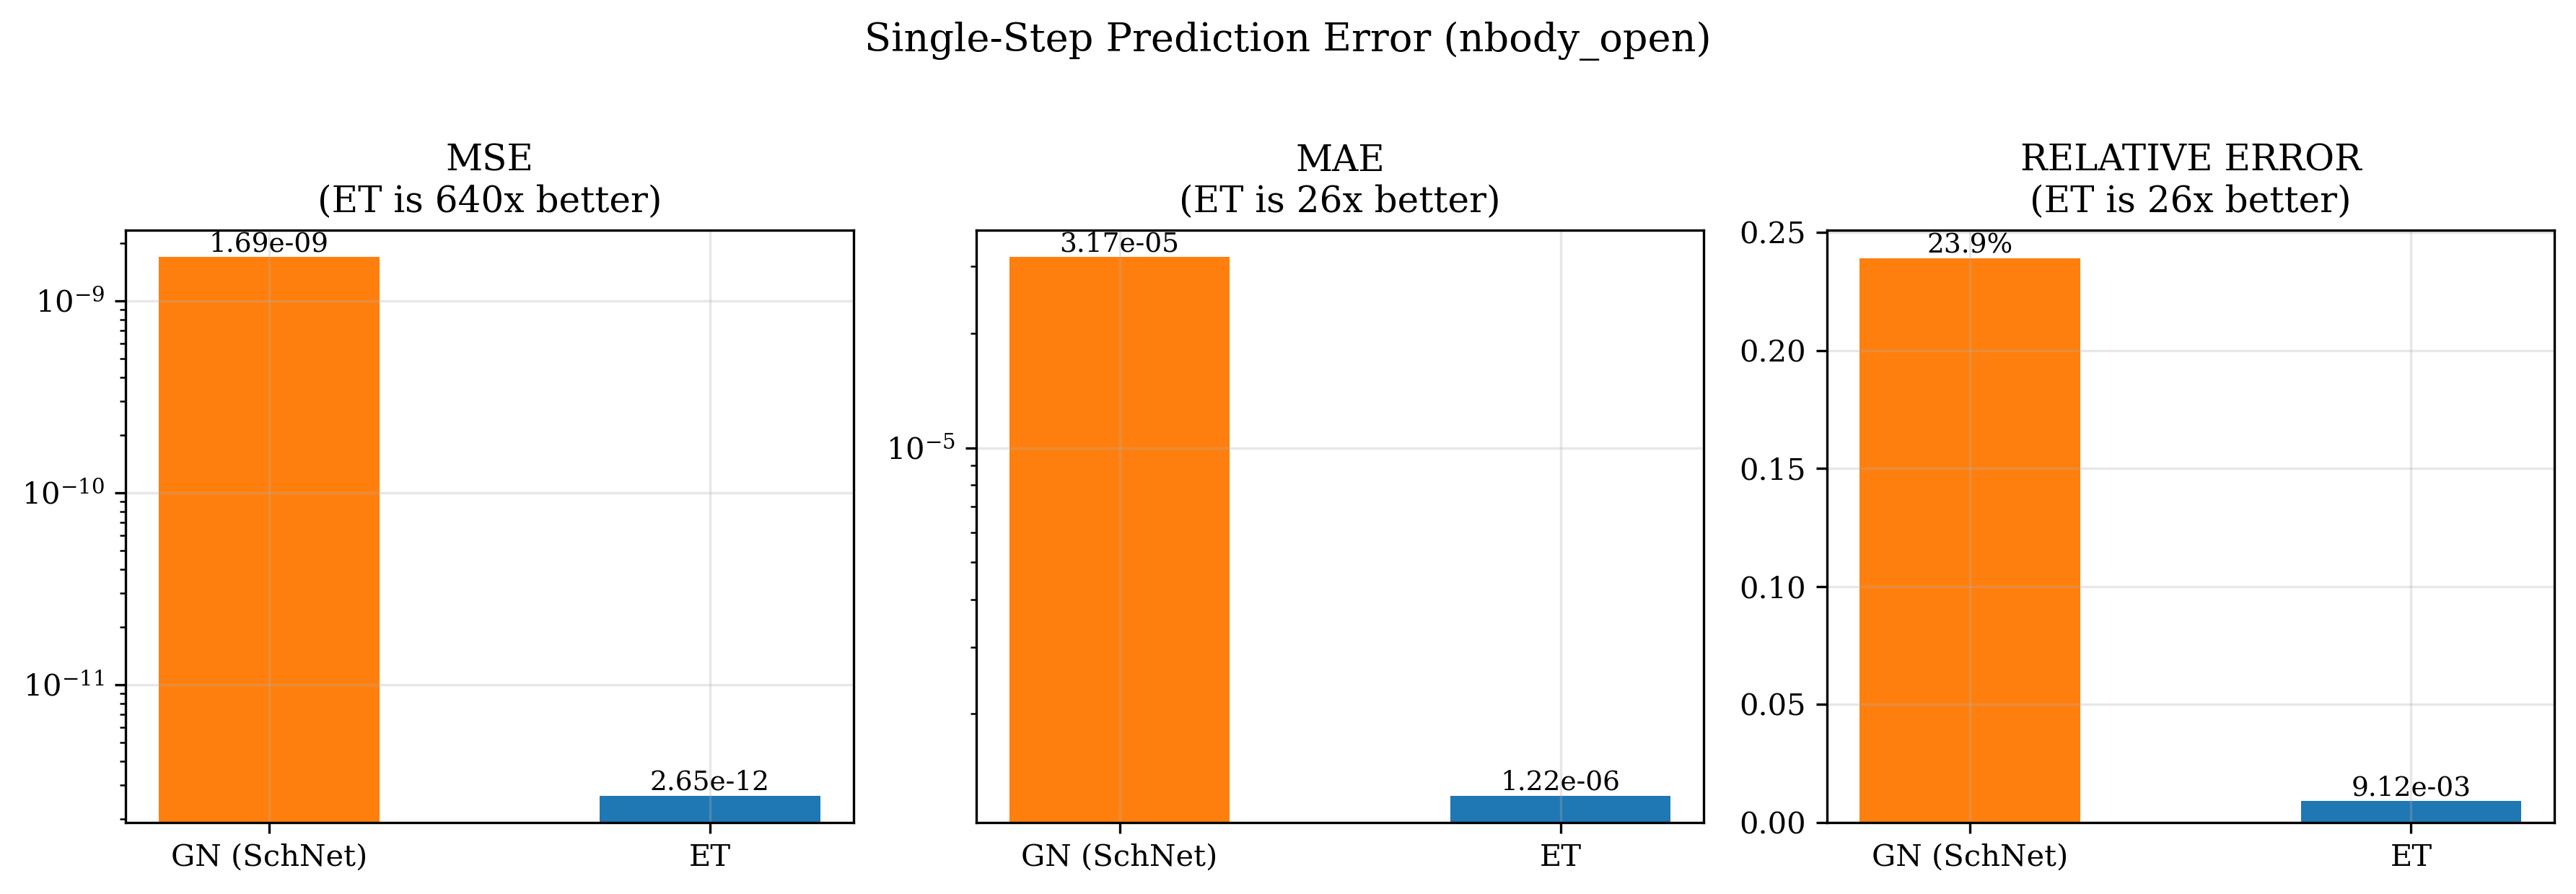

In [7]:
## Single-Step Evaluation: ET vs GN

metrics = ["mse", "mae", "relative_error"]
et_vals = [et_eval[m] for m in metrics]
gn_vals = [gn_eval[m] for m in metrics]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, (metric, et_v, gn_v) in enumerate(zip(metrics, et_vals, gn_vals)):
    ax = axes[i]
    bars = ax.bar(["GN (SchNet)", "ET"], [gn_v, et_v],
                  color=["tab:orange", "tab:blue"], width=0.5)
    
    # Improvement factor
    factor = gn_v / et_v
    ax.set_title(f"{metric.upper().replace('_', ' ')}\n(ET is {factor:.0f}x better)")
    
    if metric != "relative_error":
        ax.set_yscale("log")
    
    # Annotate bars
    for bar, val in zip(bars, [gn_v, et_v]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                f"{val:.2e}" if val < 0.01 else f"{val:.1%}",
                ha="center", va="bottom", fontsize=9)

fig.suptitle("Single-Step Prediction Error (nbody_open)", fontsize=13, y=1.02)
fig.tight_layout()
fig.savefig(plot_dir / "single_step_comparison.png")
fig.savefig(plot_dir / "single_step_comparison.pdf")
plt.show()

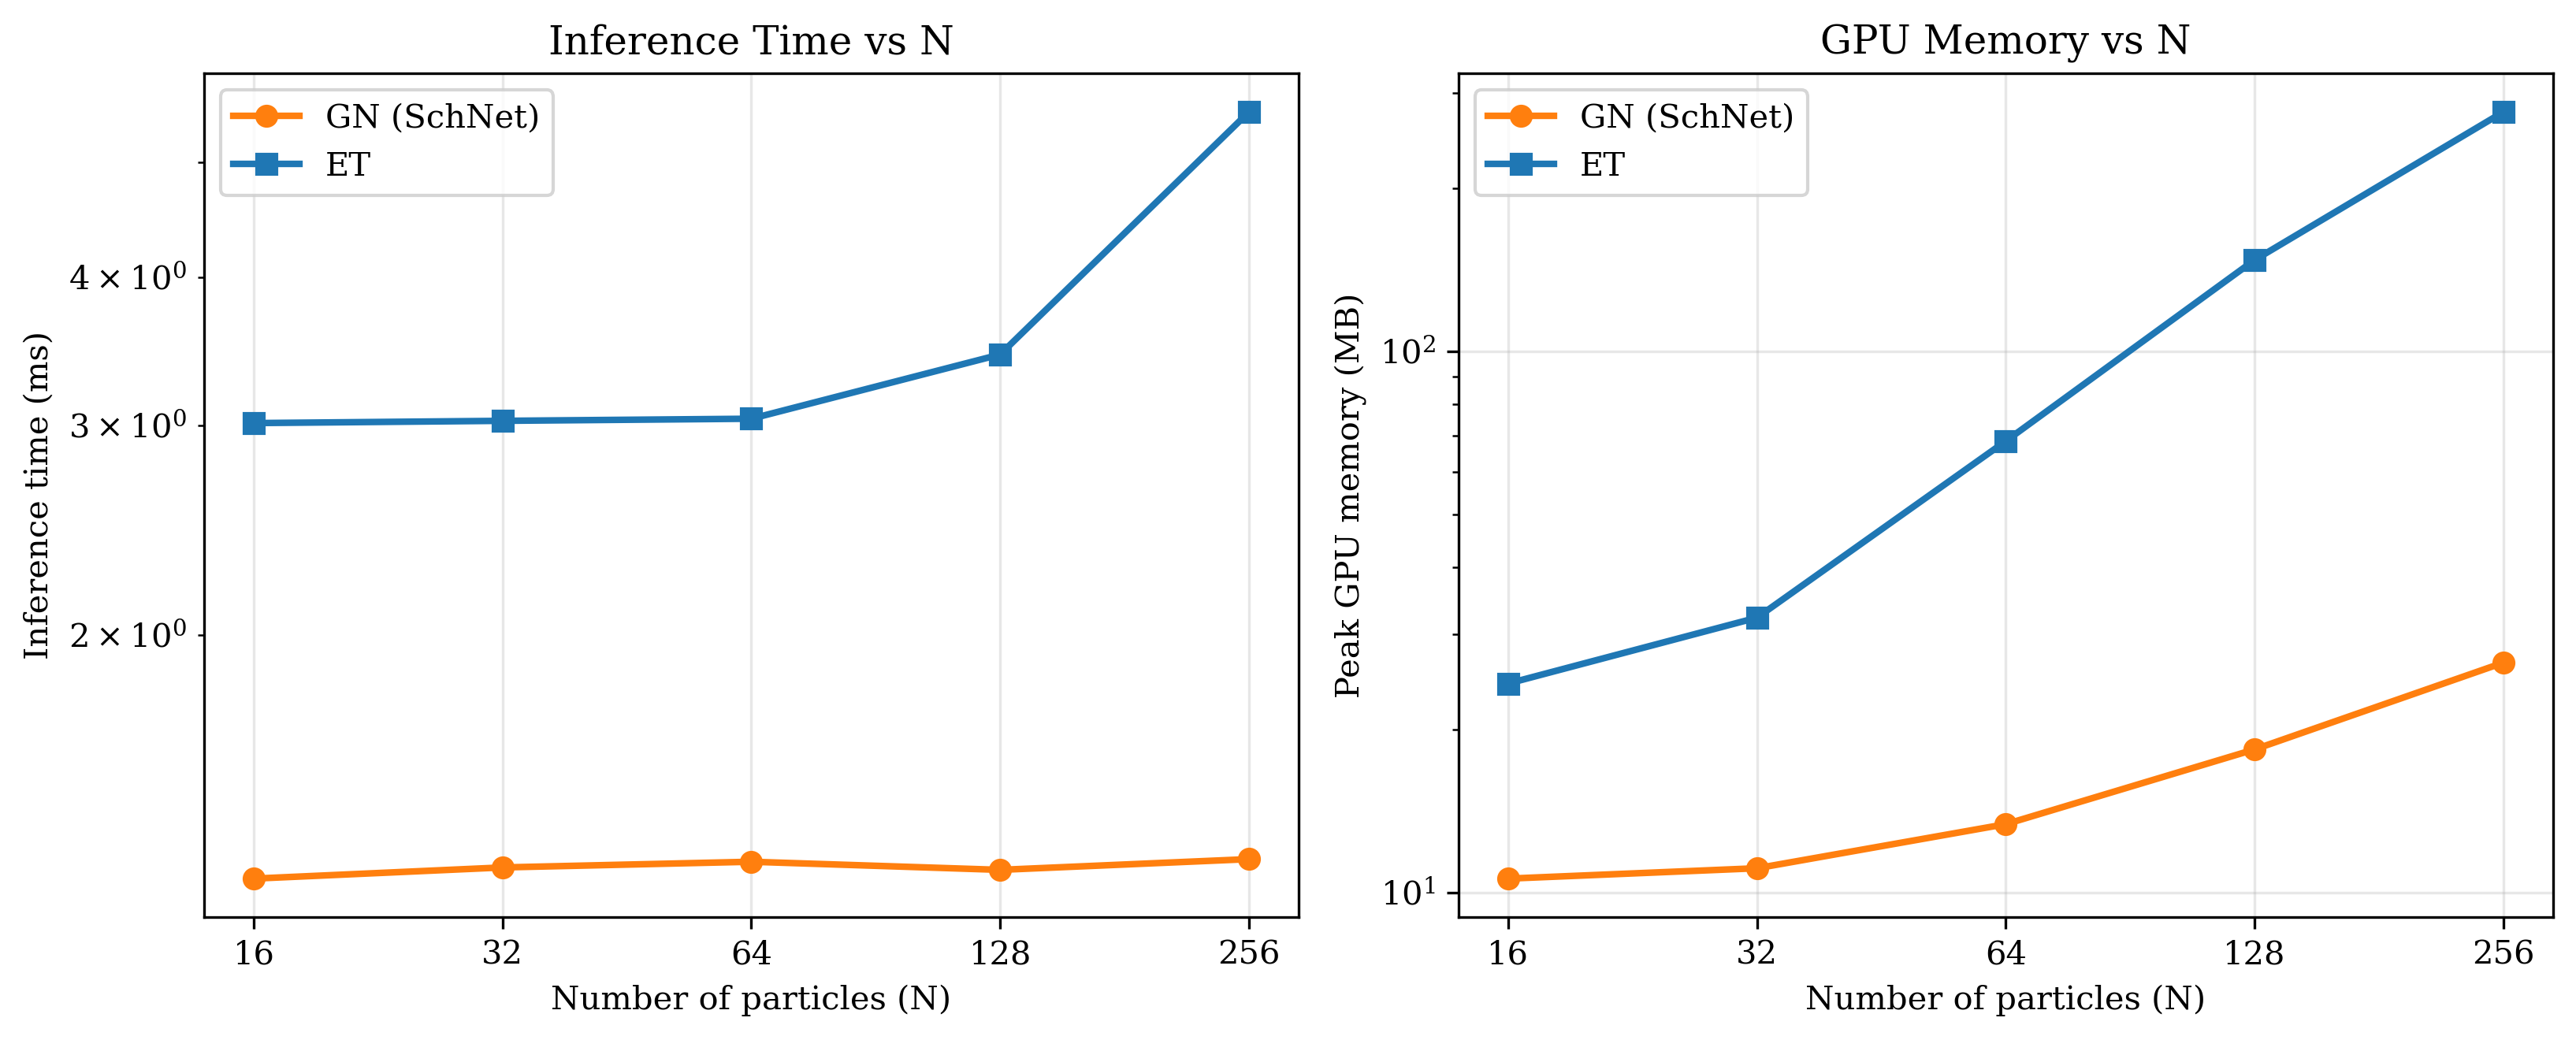

In [8]:
## Scaling: Inference Time and Memory

Ns = sorted(et_scaling.keys(), key=int)

et_times = [et_scaling[n]["time_ms"] for n in Ns]
gn_times = [gn_scaling[n]["time_ms"] for n in Ns]
et_mem = [et_scaling[n]["memory_mb"] for n in Ns]
gn_mem = [gn_scaling[n]["memory_mb"] for n in Ns]
Ns_int = [int(n) for n in Ns]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))

# Time
ax1.plot(Ns_int, gn_times, "o-", color="tab:orange", label="GN (SchNet)", linewidth=2)
ax1.plot(Ns_int, et_times, "s-", color="tab:blue", label="ET", linewidth=2)
ax1.set_xscale("log", base=2)
ax1.set_yscale("log")
ax1.set_xlabel("Number of particles (N)")
ax1.set_ylabel("Inference time (ms)")
ax1.set_title("Inference Time vs N")
ax1.legend()
ax1.set_xticks(Ns_int)
ax1.set_xticklabels(Ns_int)

# Memory
ax2.plot(Ns_int, gn_mem, "o-", color="tab:orange", label="GN (SchNet)", linewidth=2)
ax2.plot(Ns_int, et_mem, "s-", color="tab:blue", label="ET", linewidth=2)
ax2.set_xscale("log", base=2)
ax2.set_yscale("log")
ax2.set_xlabel("Number of particles (N)")
ax2.set_ylabel("Peak GPU memory (MB)")
ax2.set_title("GPU Memory vs N")
ax2.legend()
ax2.set_xticks(Ns_int)
ax2.set_xticklabels(Ns_int)

fig.tight_layout()
fig.savefig(plot_dir / "scaling_comparison.png")
fig.savefig(plot_dir / "scaling_comparison.pdf")
plt.show()

## Summary Table

| Metric | GN (SchNet) | ET (Equivariant Transformer) | Improvement |
|--------|------------|------------------------------|-------------|
| MSE | 1.69e-9 | 2.65e-12 | **638x** |
| MAE | 3.17e-5 | 1.22e-6 | **26x** |
| Relative Error | 23.9% | 0.9% | **26x** |
| Val Loss | 0.027 | 6.5e-5 | **415x** |
| Inference (N=64) | 1.3 ms | 3.0 ms | 0.4x (ET slower) |
| Memory (N=64) | 13 MB | 68 MB | 0.2x (ET larger) |

The ET pays a modest cost in compute (~2.3x slower, ~5x more memory) for a **26x improvement in accuracy**.

## Why Does the ET Win?

The mobility tensor in Stokes flow (RPY approximation) has the form:

$$M_{ij} = a(r)\,\mathbf{I} + b(r)\,\hat{r}\otimes\hat{r}$$

- **Isotropic part** $a(r)\,\mathbf{I}$: depends only on distance $\|r_{ij}\|$. Both GN and ET can learn this.
- **Anisotropic part** $b(r)\,\hat{r}\otimes\hat{r}$: depends on the *direction* $\hat{r}_{ij}$, not just the distance.

**SchNet (GN)** uses scalar messages: $m_{ij} = h_j \odot W(\|r_{ij}\|)$. These are radially symmetric — the message from particle $j$ to $i$ is the same regardless of direction. SchNet **cannot represent** the anisotropic $b(r)\,\hat{r}\otimes\hat{r}$ term. Its ~24% relative error plateau corresponds to the cross-mobility anisotropy it fundamentally cannot learn.

**Equivariant Transformer (ET)** updates vector features using the unit direction $\hat{d}_{ij}$, which breaks radial symmetry. This allows it to represent direction-dependent interactions like $b(r)\,\hat{r}\otimes\hat{r}$, achieving ~0.9% relative error.

This is a fundamental architectural limitation, not a training issue — no amount of hyperparameter tuning will close the gap for SchNet on problems with anisotropic particle interactions.

In [3]:
import torch
from torch_geometric.data import Data
from src.models.torchmd_et import HydroTorchMD_ET
from src.data.normalization import FeatureNormalizer
from src.utils.config import ModelConfig

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

path = "/home/isma/ML-for-Hydrodynamics-Multiple-Geometries/saved_models/torchmd_et_single/run_002/epoch_0500.pt"
# 1. Load model
cfg = ModelConfig(model_type="torchmd_et")
model = HydroTorchMD_ET(cfg).to(device)
ckpt = torch.load(path, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

# 2. Load normalizer (z-score stats from training)
normalizer = FeatureNormalizer()
normalizer.load("data/processed/normalizer.pt")

# 3. Prepare your datapoint — N particles
#    positions: (N, 3), forces: (N, 3), theta: (N, 6)
positions = torch.randn(16, 3)   # your particle positions
forces = torch.randn(16, 3)      # your forces
theta = torch.randn(16, 6)       # geometry encoding [geometry_id, box params...]

# 4. Normalize inputs
forces_norm = normalizer.transform(forces, "forces")
theta_norm = normalizer.transform(theta, "theta")

# 5. Build Data object
node_features = torch.cat([forces_norm, theta_norm], dim=-1)  # (N, 9)
data = Data(
    x=node_features.to(device),
    pos=positions.to(device),
)
data.batch = torch.zeros(16, dtype=torch.long, device=device)

# 6. Predict
with torch.no_grad():
    pred_disp_norm = model(data)  # (N, 3) normalized displacements

# 7. Denormalize to physical units
pred_displacement = normalizer.inverse_transform(pred_disp_norm.cpu(), "displacement")
print(pred_displacement.shape)  # (N, 3)


/home/isma/anaconda3/envs/hydro-ml/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch.Size([16, 3])


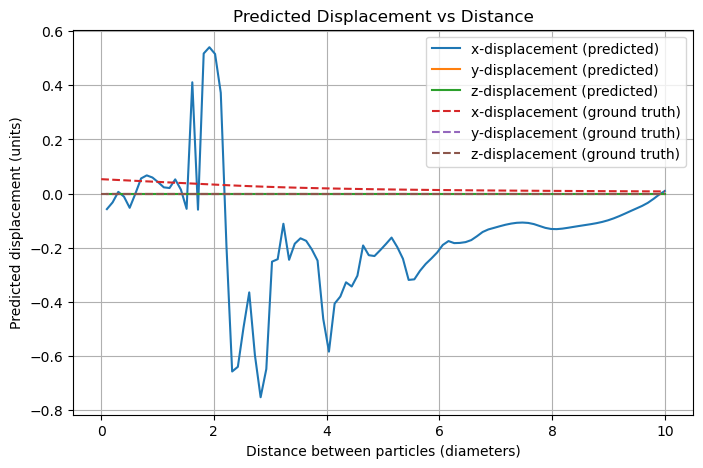

In [5]:
# Evaluate the prediction of the model for two particles with increasing distance (from 0 to 10 particle diameters) and plot the predicted displacement vs distance.
import matplotlib.pyplot as plt
# Compare with libmobility solution
import libMobility as lm
solver = lm.NBody(periodicityX="open", periodicityY="open", periodicityZ="open")
solver.initialize(viscosity=1.0, hydrodynamicRadius=1.0)
distances = torch.linspace(0, 10, steps=100)  # distances from 0 to 10 particle diameters
pred_displacements = []
ground_truth_displacements = []
for d in distances:
    # Create a two-particle system with distance d
    positions = torch.tensor([[0.0, 0.0, 0.0], [d, 0.0, 0.0]])  # Particle 1 at origin, Particle 2 at (d, 0, 0)
    forces = torch.tensor([[1.0, 0.0, 0.0], [0.0, 0.0, 0.0]])  # Random forces for both particles
    theta = torch.zeros(2, 6)    # Geometry encoding (can be zeros for this test)

    # Normalize inputs
    forces_norm = normalizer.transform(forces, "forces")
    theta_norm = normalizer.transform(theta, "theta")

    # Build Data object
    node_features = torch.cat([forces_norm, theta_norm], dim=-1)  # (2, 9)
    data = Data(
        x=node_features.to(device),
        pos=positions.to(device),
    )
    data.batch = torch.zeros(2, dtype=torch.long, device=device)

    # Predict
    with torch.no_grad():
        pred_disp_norm = model(data)  # (2, 3) normalized displacements

    # Denormalize to physical units
    pred_displacement = normalizer.inverse_transform(pred_disp_norm.cpu(), "displacement")
    
    # Get ground truth displacement from libMobility
    solver.setPositions(positions)
    dx, _ = solver.Mdot(forces=forces)

    ground_truth_displacements.append(dx[1, :])  # Relative displacement of particle 2 w.r.t particle 1

    # Store the predicted displacement of the second particle (relative to the first)
    pred_displacements.append(pred_displacement[1, :])
pred_displacements = torch.stack(pred_displacements)  # (100, 3)
ground_truth_displacements = torch.stack(ground_truth_displacements)  # (100, 3)


# Plot predicted displacement vs distance
plt.figure(figsize=(8, 5))
plt.plot(distances.numpy(), pred_displacements[:, 0].numpy(), label="x-displacement (predicted)")
plt.plot(distances.numpy(), pred_displacements[:, 1].numpy(), label="y-displacement (predicted)")
plt.plot(distances.numpy(), pred_displacements[:, 2].numpy(), label="z-displacement (predicted)")
plt.plot(distances.numpy(), ground_truth_displacements[:, 0].numpy(), "--", label="x-displacement (ground truth)")
plt.plot(distances.numpy(), ground_truth_displacements[:, 1].numpy(), "--", label="y-displacement (ground truth)")
plt.plot(distances.numpy(), ground_truth_displacements[:, 2].numpy(), "--", label="z-displacement (ground truth)")
plt.xlabel("Distance between particles (diameters)")
plt.ylabel("Predicted displacement (units)")
plt.title("Predicted Displacement vs Distance")
plt.legend()
plt.grid()
plt.show()